# Можно ли определить профессиональную роль вакансии только по требуемым технологиям?

In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

In [2]:
df = pd.read_csv(
    "../data/processed/vacancies_skills_clean.csv"
)

print(df.shape)

(516, 90)


In [4]:
SKILLS = {

    # -------------------------
    # Programming
    # -------------------------
    "python": [
        "python"
    ],

    "r": [
        " r ",
        "r language",
        "язык r"
    ],

    "java": [
        "java"
    ],

    "scala": [
        "scala"
    ],

    "cpp": [
        "c++"
    ],


    # -------------------------
    # Data analysis
    # -------------------------
    "pandas": [
        "pandas"
    ],

    "numpy": [
        "numpy"
    ],

    "scipy": [
        "scipy"
    ],

    "statsmodels": [
        "statsmodels"
    ],


    # -------------------------
    # Visualization
    # -------------------------
    "matplotlib": [
        "matplotlib"
    ],

    "seaborn": [
        "seaborn"
    ],

    "plotly": [
        "plotly"
    ],


    # -------------------------
    # BI
    # -------------------------
    "power_bi": [
        "power bi",
        "powerbi"
    ],

    "tableau": [
        "tableau"
    ],

    "excel": [
        "excel",
        "ms excel",
        "microsoft excel"
    ],

    "power_query": [
        "power query"
    ],

    "dax": [
        "dax"
    ],

    "looker": [
        "looker",
        "looker studio"
    ],

    "qlik": [
        "qlik",
        "qlik sense",
        "qlikview"
    ],

    "metabase": [
        "metabase"
    ],


    # -------------------------
    # SQL / Databases
    # -------------------------
    "sql": [
        "sql"
    ],

    "postgresql": [
        "postgresql",
        "postgres"
    ],

    "mysql": [
        "mysql"
    ],

    "ms_sql_server": [
        "mssql",
        "ms sql",
        "ms sql server",
        "microsoft sql server",
        "sql server"
    ],

    "oracle": [
        "oracle database",
        "oracle db"
    ],

    "clickhouse": [
        "clickhouse"
    ],

    "mongodb": [
        "mongodb",
        "mongo db"
    ],

    "redis": [
        "redis"
    ],

    "sqlite": [
        "sqlite"
    ],


    # -------------------------
    # Classical Machine Learning
    # -------------------------
    "scikit_learn": [
        "scikit-learn",
        "scikit learn",
        "sklearn"
    ],

    "xgboost": [
        "xgboost"
    ],

    "lightgbm": [
        "lightgbm",
        "light gbm"
    ],

    "catboost": [
        "catboost"
    ],


    # -------------------------
    # Deep Learning
    # -------------------------
    "pytorch": [
        "pytorch",
        "torch"
    ],

    "tensorflow": [
        "tensorflow"
    ],

    "keras": [
        "keras"
    ],


    # -------------------------
    # Computer Vision
    # -------------------------
    "opencv": [
        "opencv",
        "open cv"
    ],

    "yolo": [
        "yolo"
    ],


    # -------------------------
    # NLP / LLM
    # -------------------------
    "nlp": [
        "nlp",
        "natural language processing"
    ],

    "transformers": [
        "transformers"
    ],

    "huggingface": [
        "hugging face",
        "huggingface"
    ],

    "llm": [
        "llm",
        "large language model",
        "large language models"
    ],

    "rag": [
        "rag",
        "retrieval augmented generation",
        "retrieval-augmented generation"
    ],

    "langchain": [
        "langchain"
    ],

    "llamaindex": [
        "llamaindex",
        "llama index"
    ],

    "openai_api": [
        "openai api"
    ],


    # -------------------------
    # Big Data / Data Engineering
    # -------------------------
    "spark": [
        "apache spark",
        "pyspark",
        "spark"
    ],

    "hadoop": [
        "hadoop"
    ],

    "kafka": [
        "apache kafka",
        "kafka"
    ],

    "airflow": [
        "apache airflow",
        "airflow"
    ],

    "dbt": [
        "dbt",
        "data build tool"
    ],

    "hive": [
        "apache hive",
        "hive"
    ],

    "snowflake": [
        "snowflake"
    ],

    "bigquery": [
        "bigquery",
        "big query"
    ],

    "databricks": [
        "databricks"
    ],


    # -------------------------
    # MLOps / DevOps
    # -------------------------
    "docker": [
        "docker"
    ],

    "kubernetes": [
        "kubernetes",
        "k8s"
    ],

    "mlflow": [
        "mlflow"
    ],

    "dvc": [
        "dvc",
        "data version control"
    ],

    "git": [
        "git"
    ],

    "github": [
        "github"
    ],

    "gitlab": [
        "gitlab"
    ],

    "jenkins": [
        "jenkins"
    ],

    "ci_cd": [
        "ci/cd",
        "ci cd",
        "continuous integration"
    ],


    # -------------------------
    # Cloud
    # -------------------------
    "aws": [
        "aws",
        "amazon web services"
    ],

    "azure": [
        "microsoft azure",
        "azure"
    ],

    "gcp": [
        "gcp",
        "google cloud",
        "google cloud platform"
    ],


    # -------------------------
    # Backend / API
    # -------------------------
    "fastapi": [
        "fastapi",
        "fast api"
    ],

    "flask": [
        "flask"
    ],

    "django": [
        "django"
    ],

    "rest_api": [
        "rest api",
        "restful",
        "rest-api"
    ],


    # -------------------------
    # Other analytics tools
    # -------------------------
    "jupyter": [
        "jupyter",
        "jupyter notebook"
    ],

    "notebook": [
        "notebook"
    ],

    "sas": [
        "sas"
    ],

    "spss": [
        "spss"
    ]
}
skill_columns = list(SKILLS.keys())


In [5]:
X = df[skill_columns]

y = df["role"]

In [6]:
print(
    "X:",
    X.shape
)

print(
    "y:",
    y.shape
)

print()

print(
    y.value_counts()
)

X: (516, 75)
y: (516,)

role
Data Analyst        119
ML Engineer          88
Data Scientist       81
Data Engineer        64
AI Engineer          52
Python Developer     46
BI Analyst           37
MLOps Engineer       29
Name: count, dtype: int64


In [ ]:
X_train, X_test, y_train, y_test = (
    train_test_split(
        X,
        y,
        test_size=0.25,
        random_state=42,
        stratify=y #старается сохранить примерно одинаковые пропорции профессий и в train, и в test.
    )
)

In [8]:
print(
    "Train:",
    X_train.shape
)

print(
    "Test:",
    X_test.shape
)

print()

print(
    y_train.value_counts(normalize=True)
)

print()

print(
    y_test.value_counts(normalize=True)
)

Train: (387, 75)
Test: (129, 75)

role
Data Analyst        0.229974
ML Engineer         0.170543
Data Scientist      0.157623
Data Engineer       0.124031
AI Engineer         0.100775
Python Developer    0.087855
BI Analyst          0.072351
MLOps Engineer      0.056848
Name: proportion, dtype: float64

role
Data Analyst        0.232558
ML Engineer         0.170543
Data Scientist      0.155039
Data Engineer       0.124031
AI Engineer         0.100775
Python Developer    0.093023
BI Analyst          0.069767
MLOps Engineer      0.054264
Name: proportion, dtype: float64


In [9]:
logreg = LogisticRegression(
    max_iter=2000,
    random_state=42
)

In [10]:
logreg.fit(
    X_train,
    y_train
)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",2000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lb

In [11]:
y_pred_logreg = logreg.predict(
    X_test
)

In [12]:
accuracy = accuracy_score(
    y_test,
    y_pred_logreg
)

print(
    "Accuracy:",
    round(accuracy, 3)
)

Accuracy: 0.612


In [13]:
precision_macro = precision_score(
    y_test,
    y_pred_logreg,
    average="macro",
    zero_division=0
)

recall_macro = recall_score(
    y_test,
    y_pred_logreg,
    average="macro",
    zero_division=0
)

f1_macro = f1_score(
    y_test,
    y_pred_logreg,
    average="macro",
    zero_division=0
)

In [14]:
print(
    "Precision macro:",
    round(precision_macro, 3)
)

print(
    "Recall macro:",
    round(recall_macro, 3)
)

print(
    "F1 macro:",
    round(f1_macro, 3)
)

Precision macro: 0.65
Recall macro: 0.598
F1 macro: 0.616


In [15]:
print(
    classification_report(
        y_test,
        y_pred_logreg,
        zero_division=0
    )
)

                  precision    recall  f1-score   support

     AI Engineer       0.67      0.62      0.64        13
      BI Analyst       0.60      0.33      0.43         9
    Data Analyst       0.62      0.80      0.70        30
   Data Engineer       0.59      0.62      0.61        16
  Data Scientist       0.42      0.40      0.41        20
     ML Engineer       0.57      0.55      0.56        22
  MLOps Engineer       0.83      0.71      0.77         7
Python Developer       0.90      0.75      0.82        12

        accuracy                           0.61       129
       macro avg       0.65      0.60      0.62       129
    weighted avg       0.62      0.61      0.61       129



In [16]:
logreg_metrics = {
    "model": "Logistic Regression",
    "accuracy": accuracy_score(
        y_test,
        y_pred_logreg
    ),
    "precision_macro": precision_score(
        y_test,
        y_pred_logreg,
        average="macro",
        zero_division=0
    ),
    "recall_macro": recall_score(
        y_test,
        y_pred_logreg,
        average="macro",
        zero_division=0
    ),
    "f1_macro": f1_score(
        y_test,
        y_pred_logreg,
        average="macro",
        zero_division=0
    )
}

logreg_metrics

{'model': 'Logistic Regression',
 'accuracy': 0.6124031007751938,
 'precision_macro': 0.6495126390637227,
 'recall_macro': 0.5979322760572761,
 'f1_macro': 0.6157615926372246}

In [17]:
cm_logreg = confusion_matrix(
    y_test,
    y_pred_logreg,
    labels=logreg.classes_
)

print(cm_logreg)

[[ 8  0  0  1  0  3  0  1]
 [ 0  3  6  0  0  0  0  0]
 [ 0  2 24  3  1  0  0  0]
 [ 0  0  5 10  0  1  0  0]
 [ 1  0  3  3  8  5  0  0]
 [ 1  0  0  0  8 12  1  0]
 [ 1  0  1  0  0  0  5  0]
 [ 1  0  0  0  2  0  0  9]]


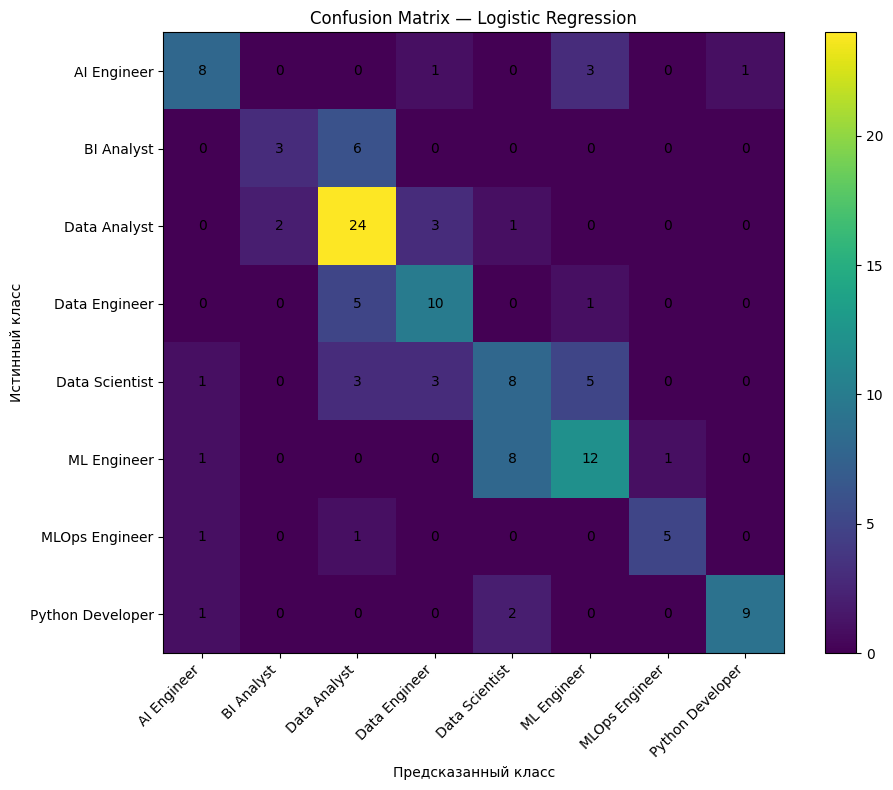

In [19]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(
    figsize=(10, 8)
)

image = ax.imshow(
    cm_logreg
)

ax.set_xticks(
    range(len(logreg.classes_))
)

ax.set_yticks(
    range(len(logreg.classes_))
)

ax.set_xticklabels(
    logreg.classes_,
    rotation=45,
    ha="right"
)

ax.set_yticklabels(
    logreg.classes_
)

ax.set_xlabel(
    "Предсказанный класс"
)

ax.set_ylabel(
    "Истинный класс"
)

ax.set_title(
    "Confusion Matrix — Logistic Regression"
)

for i in range(cm_logreg.shape[0]):
    for j in range(cm_logreg.shape[1]):

        ax.text(
            j,
            i,
            cm_logreg[i, j],
            ha="center",
            va="center"
        )

plt.colorbar(image)

plt.tight_layout()

plt.savefig(
    "../images/confusion_matrix_logreg.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [23]:
cm_logreg_norm = confusion_matrix(
    y_test,
    y_pred_logreg,
    labels=logreg.classes_,
    normalize="true"
)
cm_logreg_norm

array([[0.61538462, 0.        , 0.        , 0.07692308, 0.        ,
        0.23076923, 0.        , 0.07692308],
       [0.        , 0.33333333, 0.66666667, 0.        , 0.        ,
        0.        , 0.        , 0.        ],
       [0.        , 0.06666667, 0.8       , 0.1       , 0.03333333,
        0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.3125    , 0.625     , 0.        ,
        0.0625    , 0.        , 0.        ],
       [0.05      , 0.        , 0.15      , 0.15      , 0.4       ,
        0.25      , 0.        , 0.        ],
       [0.04545455, 0.        , 0.        , 0.        , 0.36363636,
        0.54545455, 0.04545455, 0.        ],
       [0.14285714, 0.        , 0.14285714, 0.        , 0.        ,
        0.        , 0.71428571, 0.        ],
       [0.08333333, 0.        , 0.        , 0.        , 0.16666667,
        0.        , 0.        , 0.75      ]])

In [22]:
cm_logreg_percent = (
    cm_logreg_norm
    * 100
)
cm_logreg_percent

array([[61.53846154,  0.        ,  0.        ,  7.69230769,  0.        ,
        23.07692308,  0.        ,  7.69230769],
       [ 0.        , 33.33333333, 66.66666667,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ],
       [ 0.        ,  6.66666667, 80.        , 10.        ,  3.33333333,
         0.        ,  0.        ,  0.        ],
       [ 0.        ,  0.        , 31.25      , 62.5       ,  0.        ,
         6.25      ,  0.        ,  0.        ],
       [ 5.        ,  0.        , 15.        , 15.        , 40.        ,
        25.        ,  0.        ,  0.        ],
       [ 4.54545455,  0.        ,  0.        ,  0.        , 36.36363636,
        54.54545455,  4.54545455,  0.        ],
       [14.28571429,  0.        , 14.28571429,  0.        ,  0.        ,
         0.        , 71.42857143,  0.        ],
       [ 8.33333333,  0.        ,  0.        ,  0.        , 16.66666667,
         0.        ,  0.        , 75.        ]])

In [24]:
random_forest = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)

In [25]:
random_forest.fit(
    X_train,
    y_train
)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"class_weight class_weight: {""balanced"", ""balanced_subsample""}, dict or list of dicts, default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``The ""balanced_subsample"" mode is the same as ""balanced"" except thatweights are computed based on the bootstrap sample for every treegrown.For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.",'balanced'
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_fe

In [26]:
y_pred_rf = random_forest.predict(
    X_test
)

In [27]:
print(
    classification_report(
        y_test,
        y_pred_rf,
        zero_division=0
    )
)

                  precision    recall  f1-score   support

     AI Engineer       0.54      0.54      0.54        13
      BI Analyst       0.50      0.67      0.57         9
    Data Analyst       0.75      0.70      0.72        30
   Data Engineer       0.63      0.75      0.69        16
  Data Scientist       0.56      0.45      0.50        20
     ML Engineer       0.55      0.55      0.55        22
  MLOps Engineer       0.83      0.71      0.77         7
Python Developer       0.77      0.83      0.80        12

        accuracy                           0.64       129
       macro avg       0.64      0.65      0.64       129
    weighted avg       0.64      0.64      0.63       129



In [28]:
rf_accuracy = accuracy_score(
    y_test,
    y_pred_rf
)

rf_precision = precision_score(
    y_test,
    y_pred_rf,
    average="macro",
    zero_division=0
)

rf_recall = recall_score(
    y_test,
    y_pred_rf,
    average="macro",
    zero_division=0
)

rf_f1 = f1_score(
    y_test,
    y_pred_rf,
    average="macro",
    zero_division=0
)

print(
    "Accuracy:",
    round(rf_accuracy, 3)
)

print(
    "Precision macro:",
    round(rf_precision, 3)
)

print(
    "Recall macro:",
    round(rf_recall, 3)
)

print(
    "Macro F1:",
    round(rf_f1, 3)
)

Accuracy: 0.636
Precision macro: 0.641
Recall macro: 0.65
Macro F1: 0.642


In [29]:
rf_metrics = {
    "model": "Random Forest",
    "accuracy": rf_accuracy,
    "precision_macro": rf_precision,
    "recall_macro": rf_recall,
    "f1_macro": rf_f1
}

In [30]:
model_comparison = pd.DataFrame(
    [
        logreg_metrics,
        rf_metrics
    ]
)

display(
    model_comparison.round(3)
)

,model,accuracy,precision_macro,recall_macro,f1_macro
0,Logistic Regression,0.612,0.650,0.598,0.616
1,Random Forest,0.636,0.641,0.650,0.642


In [31]:
cm_rf = confusion_matrix(
    y_test,
    y_pred_rf,
    labels=random_forest.classes_
)

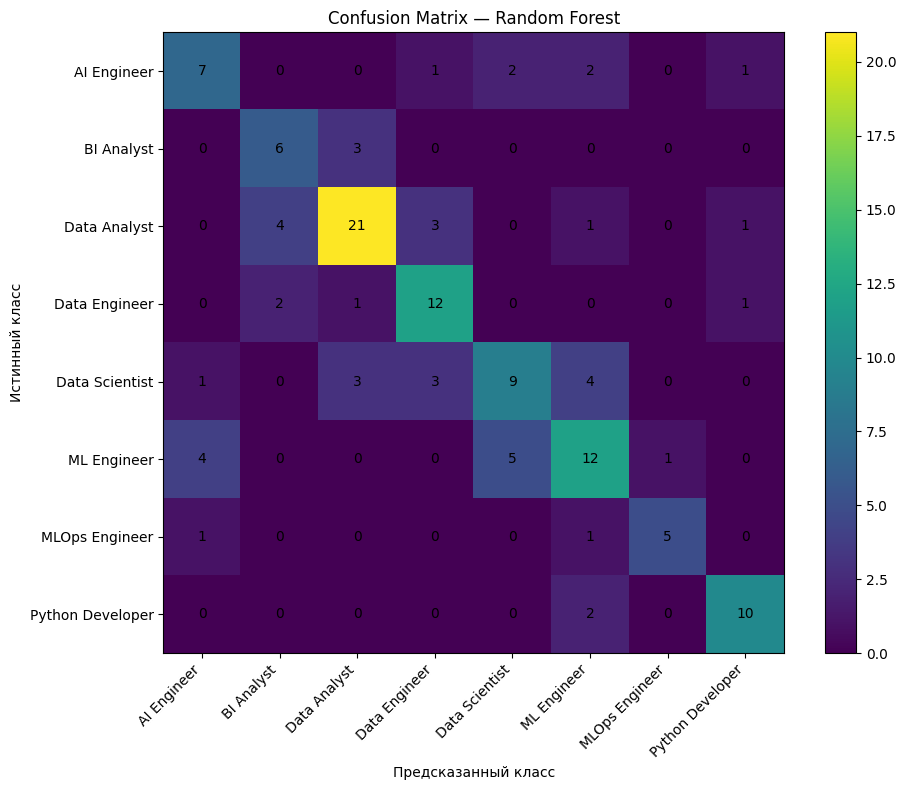

In [32]:
fig, ax = plt.subplots(
    figsize=(10, 8)
)

image = ax.imshow(
    cm_rf
)

ax.set_xticks(
    range(len(random_forest.classes_))
)

ax.set_yticks(
    range(len(random_forest.classes_))
)

ax.set_xticklabels(
    random_forest.classes_,
    rotation=45,
    ha="right"
)

ax.set_yticklabels(
    random_forest.classes_
)

ax.set_xlabel(
    "Предсказанный класс"
)

ax.set_ylabel(
    "Истинный класс"
)

ax.set_title(
    "Confusion Matrix — Random Forest"
)

for i in range(cm_rf.shape[0]):
    for j in range(cm_rf.shape[1]):

        ax.text(
            j,
            i,
            cm_rf[i, j],
            ha="center",
            va="center"
        )

plt.colorbar(image)

plt.tight_layout()

plt.savefig(
    "../images/confusion_matrix_random_forest.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:
#что сильнее всего помогает найти нужную вакансию

feature_importance = pd.Series(
    random_forest.feature_importances_,
    index=skill_columns
)
feature_importance = (
    feature_importance
    .sort_values(
        ascending=False
    )
)
print(
    feature_importance.head(20)
)

kubernetes    0.040527
airflow       0.040467
sql           0.039364
power_bi      0.037938
docker        0.034691
ci_cd         0.034669
fastapi       0.033085
llm           0.032424
pytorch       0.032352
postgresql    0.031781
python        0.030628
spark         0.029315
rag           0.028213
git           0.024196
tableau       0.023565
langchain     0.022053
mlflow        0.021689
gitlab        0.021032
pandas        0.020954
nlp           0.020947
dtype: float64


In [36]:
results = pd.DataFrame({
    "actual": y_test,
    "predicted": y_pred_rf
})
results["correct"] = (
    results["actual"]
    == results["predicted"]
)

errors = results[
    results["correct"] == False
]

display(
    errors.head(30)
)

,actual,predicted,correct
180,Data Scientist,Data Analyst,False
457,ML Engineer,AI Engineer,False
32,BI Analyst,Data Analyst,False
15,Data Analyst,Data Engineer,False
288,AI Engineer,ML Engineer,False
343,Data Engineer,Python Developer,False
297,ML Engineer,Data Scientist,False
159,Data Scientist,Data Engineer,False
112,Data Analyst,BI Analyst,False
493,Python Developer,ML Engineer,False


In [37]:
error_pairs = (
    errors
    .groupby(
        [
            "actual",
            "predicted"
        ]
    )
    .size()
    .sort_values(
        ascending=False
    )
)

print(
    error_pairs.head(20)
)

actual            predicted       
ML Engineer       Data Scientist      5
Data Analyst      BI Analyst          4
Data Scientist    ML Engineer         4
ML Engineer       AI Engineer         4
Data Analyst      Data Engineer       3
BI Analyst        Data Analyst        3
Data Scientist    Data Engineer       3
                  Data Analyst        3
AI Engineer       Data Scientist      2
                  ML Engineer         2
Data Engineer     BI Analyst          2
Python Developer  ML Engineer         2
AI Engineer       Python Developer    1
                  Data Engineer       1
Data Scientist    AI Engineer         1
Data Engineer     Python Developer    1
                  Data Analyst        1
Data Analyst      Python Developer    1
                  ML Engineer         1
ML Engineer       MLOps Engineer      1
dtype: int64


In [42]:
error_details = df.loc[
    errors.index,
    [
        "title",
        "role",
        "skills",
        "experience"
    ]
].copy()

error_details["predicted"] = (
    errors["predicted"]
)

display(
    error_details.head(30)
)

,title,role,skills,experience,predicted
180,Аналитик отдела продаж / Data Analyst / Data S...,Data Scientist,"['excel', 'sql']",Опыт 1-3 года,Data Analyst
457,ML-инженер (нефтетрейдинговая компания),ML Engineer,"['python', 'sql', 'pytorch', 'tensorflow', 'nl...",Опыт 3-6 лет,AI Engineer
32,Аналитик данных (BI аналитик),BI Analyst,"['python', 'pandas', 'numpy', 'power_bi', 'tab...",Опыт 1-3 года,Data Analyst
15,Аналитик данных/Инженер по качеству данных,Data Analyst,"['python', 'java', 'pandas', 'numpy', 'qlik', ...",Опыт 3-6 лет,Data Engineer
288,Senior AI engineer,AI Engineer,"['python', 'sql', 'llm', 'rag', 'llamaindex', ...",Опыт 3-6 лет,ML Engineer
343,Data Engineer (Python),Data Engineer,"['python', 'postgresql', 'mysql', 'llm', 'rag'...",Опыт 1-3 года,Python Developer
297,ML engineer (invest tech),ML Engineer,"['python', 'cpp', 'sql', 'postgresql', 'clickh...",Опыт 3-6 лет,Data Scientist
159,Junior Data Scientist (Pricing),Data Scientist,"['python', 'pandas', 'sql', 'airflow']",Без опыта,Data Engineer
112,Аналитик данных \ Data Analyst,Data Analyst,"['power_bi', 'power_query', 'dax', 'sql', 'pos...",Опыт 3-6 лет,BI Analyst
493,Python Developer (CAD Automation),Python Developer,['python'],Без опыта,ML Engineer


In [43]:
from sklearn.model_selection import (
    StratifiedKFold,
    cross_validate
)

In [44]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [45]:
logreg_cv = cross_validate(
    logreg,
    X_train,
    y_train,
    cv=cv,
    scoring=[
        "accuracy",
        "precision_macro",
        "recall_macro",
        "f1_macro"
    ],
    n_jobs=-1
)

In [46]:
print(
    "Logistic Regression"
)

print(
    "Accuracy:",
    logreg_cv["test_accuracy"].mean()
)

print(
    "Macro F1:",
    logreg_cv["test_f1_macro"].mean()
)

Logistic Regression
Accuracy: 0.5241425241425242
Macro F1: 0.5048615355367273


In [47]:
print(
    "Macro F1:",
    round(
        logreg_cv["test_f1_macro"].mean(),
        3
    ),
    "+/-",
    round(
        logreg_cv["test_f1_macro"].std(),
        3
    )
)

Macro F1: 0.505 +/- 0.066


In [48]:
rf_cv = cross_validate(
    random_forest,
    X_train,
    y_train,
    cv=cv,
    scoring=[
        "accuracy",
        "precision_macro",
        "recall_macro",
        "f1_macro"
    ],
    n_jobs=-1
)

In [49]:
print(
    "Random Forest"
)

print(
    "Accuracy:",
    round(
        rf_cv["test_accuracy"].mean(),
        3
    )
)

print(
    "Macro F1:",
    round(
        rf_cv["test_f1_macro"].mean(),
        3
    ),
    "+/-",
    round(
        rf_cv["test_f1_macro"].std(),
        3
    )
)

Random Forest
Accuracy: 0.542
Macro F1: 0.539 +/- 0.058


In [50]:
from sklearn.dummy import DummyClassifier
dummy = DummyClassifier(
    strategy="most_frequent"
)

dummy.fit(
    X_train,
    y_train
)

y_pred_dummy = dummy.predict(
    X_test
)

In [51]:
print(
    "Dummy Accuracy:",
    round(
        accuracy_score(
            y_test,
            y_pred_dummy
        ),
        3
    )
)

print(
    "Dummy Macro F1:",
    round(
        f1_score(
            y_test,
            y_pred_dummy,
            average="macro",
            zero_division=0
        ),
        3
    )
)

Dummy Accuracy: 0.233
Dummy Macro F1: 0.047


In [52]:
print(
    "Logistic Regression F1:"
)

print(
    logreg_cv["test_f1_macro"]
)

Logistic Regression F1:
[0.54440421 0.60826007 0.41961068 0.49093785 0.46109487]


In [53]:
print(
    "Random Forest F1:"
)

print(
    rf_cv["test_f1_macro"]
)

Random Forest F1:
[0.57874129 0.60239692 0.43453636 0.55094101 0.5271363 ]


In [54]:
cv_results = pd.DataFrame({
    "fold": [1, 2, 3, 4, 5],

    "Logistic Regression": (
        logreg_cv["test_f1_macro"]
    ),

    "Random Forest": (
        rf_cv["test_f1_macro"]
    )
})

display(
    cv_results.round(3)
)

,fold,Logistic Regression,Random Forest
0,1,0.544,0.579
1,2,0.608,0.602
2,3,0.420,0.435
3,4,0.491,0.551
4,5,0.461,0.527


In [55]:
RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"class_weight class_weight: {""balanced"", ""balanced_subsample""}, dict or list of dicts, default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``The ""balanced_subsample"" mode is the same as ""balanced"" except thatweights are computed based on the bootstrap sample for every treegrown.For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.",'balanced'
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_fe

In [56]:
from sklearn.model_selection import GridSearchCV

In [57]:
rf_params = {
    "n_estimators": [
        200,
        400
    ],

    "max_depth": [
        None,
        10,
        20
    ],

    "min_samples_split": [
        2,
        5
    ],

    "min_samples_leaf": [
        1,
        2
    ],

    "max_features": [
        "sqrt",
        0.5
    ]
}

In [58]:
rf_grid = GridSearchCV(
    estimator=RandomForestClassifier(
        random_state=42,
        class_weight="balanced",
        n_jobs=-1
    ),

    param_grid=rf_params,

    scoring="f1_macro",

    cv=cv,

    n_jobs=-1
)

In [59]:
rf_grid.fit(
    X_train,
    y_train
)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [None, 10, ...], 'max_features': ['sqrt', 0.5], 'min_samples_leaf': [1, 2], 'min_samples_split': [2, 5], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1_macro'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support

In [60]:
print(
    "Best params:"
)

print(
    rf_grid.best_params_
)

print()

print(
    "Best CV Macro F1:",
    round(
        rf_grid.best_score_,
        3
    )
)

Best params:
{'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 400}

Best CV Macro F1: 0.55


In [61]:
best_rf = (
    rf_grid.best_estimator_
)

In [62]:
y_pred_best_rf = best_rf.predict(
    X_test
)

In [63]:
print(
    classification_report(
        y_test,
        y_pred_best_rf,
        zero_division=0
    )
)

                  precision    recall  f1-score   support

     AI Engineer       0.62      0.77      0.69        13
      BI Analyst       0.36      0.56      0.43         9
    Data Analyst       0.70      0.63      0.67        30
   Data Engineer       0.69      0.69      0.69        16
  Data Scientist       0.50      0.40      0.44        20
     ML Engineer       0.61      0.50      0.55        22
  MLOps Engineer       0.67      0.86      0.75         7
Python Developer       0.77      0.83      0.80        12

        accuracy                           0.62       129
       macro avg       0.62      0.65      0.63       129
    weighted avg       0.63      0.62      0.62       129



In [64]:
best_rf_accuracy = accuracy_score(
    y_test,
    y_pred_best_rf
)

best_rf_f1 = f1_score(
    y_test,
    y_pred_best_rf,
    average="macro",
    zero_division=0
)

print(
    "Final Accuracy:",
    round(best_rf_accuracy, 3)
)

print(
    "Final Macro F1:",
    round(best_rf_f1, 3)
)

Final Accuracy: 0.62
Final Macro F1: 0.628


In [65]:
logreg_balanced = LogisticRegression(
    max_iter=3000,
    class_weight="balanced",
    random_state=42
)

In [66]:
logreg_balanced_cv = cross_validate(
    logreg_balanced,
    X_train,
    y_train,
    cv=cv,
    scoring=[
        "accuracy",
        "f1_macro"
    ],
    n_jobs=-1
)

In [67]:
print(
    "Balanced Logistic Regression"
)

print(
    "Accuracy:",
    round(
        logreg_balanced_cv[
            "test_accuracy"
        ].mean(),
        3
    )
)

print(
    "Macro F1:",
    round(
        logreg_balanced_cv[
            "test_f1_macro"
        ].mean(),
        3
    )
)

Balanced Logistic Regression
Accuracy: 0.496
Macro F1: 0.508


In [68]:
print(
    "Best CV Macro F1:",
    rf_grid.best_score_
)

print(
    "Best parameters:"
)

print(
    rf_grid.best_params_
)

Best CV Macro F1: 0.5503848484711
Best parameters:
{'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 400}


In [69]:
final_results = pd.DataFrame({
    "Model": [
        "Dummy",
        "Logistic Regression",
        "Random Forest",
        "Tuned Random Forest"
    ],

    "CV Macro F1": [
        None,
        logreg_cv["test_f1_macro"].mean(),
        rf_cv["test_f1_macro"].mean(),
        rf_grid.best_score_
    ],

    "Test Macro F1": [
        0.047,
        0.616,
        0.642,
        0.628
    ]
})

display(
    final_results.round(3)
)

,Model,CV Macro F1,Test Macro F1
0,Dummy,NaN,0.047
1,Logistic Regression,0.505,0.616
2,Random Forest,0.539,0.642
3,Tuned Random Forest,0.550,0.628


In [70]:
dummy_cv = cross_validate(
    dummy,
    X_train,
    y_train,
    cv=cv,
    scoring=[
        "accuracy",
        "f1_macro"
    ],
    n_jobs=-1
)

print(
    "Dummy CV Accuracy:",
    round(
        dummy_cv["test_accuracy"].mean(),
        3
    )
)

print(
    "Dummy CV Macro F1:",
    round(
        dummy_cv["test_f1_macro"].mean(),
        3
    )
)

Dummy CV Accuracy: 0.23
Dummy CV Macro F1: 0.047


In [71]:
final_results = pd.DataFrame({

    "Model": [
        "Dummy",
        "Logistic Regression",
        "Random Forest",
        "Tuned Random Forest"
    ],

    "CV Macro F1": [
        dummy_cv["test_f1_macro"].mean(),
        logreg_cv["test_f1_macro"].mean(),
        rf_cv["test_f1_macro"].mean(),
        rf_grid.best_score_
    ],

    "Test Macro F1": [
        0.047,
        0.616,
        0.642,
        0.628
    ]
})

display(
    final_results.round(3)
)

,Model,CV Macro F1,Test Macro F1
0,Dummy,0.047,0.047
1,Logistic Regression,0.505,0.616
2,Random Forest,0.539,0.642
3,Tuned Random Forest,0.550,0.628


In [72]:
import joblib
joblib.dump(
    best_rf,
    "../models/best_random_forest.joblib"
)

['../models/best_random_forest.joblib']

In [73]:
model = joblib.load(
    "../models/best_random_forest.joblib"
)

В задаче многоклассовой классификации профессиональной роли по технологическому стеку были рассмотрены Dummy Classifier, Logistic Regression и Random Forest.

Dummy Classifier показал крайне низкое качество (Test Macro F1 = 0.047), что подтверждает необходимость использования информативных признаков и машинного обучения.

Logistic Regression достигла среднего Macro F1 = 0.505 по 5-fold cross-validation, а Random Forest — 0.539.

После настройки гиперпараметров Random Forest с помощью GridSearchCV средний Macro F1 увеличился до 0.550. На отложенной тестовой выборке настроенная модель достигла Macro F1 = 0.628.

Наибольшие трудности классификации наблюдались между технологически близкими направлениями Data Scientist, ML Engineer и AI Engineer. Это указывает на значительное пересечение технологических стеков современных Data/AI-профессий.
